In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, mean_absolute_error, mean_squared_error, r2_score

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler

import joblib

Cargar los datos que vamos a usar todos

In [2]:
X_train = pd.read_csv("../Filtrado/X_train_Escalado.csv", encoding="utf-8")
X_test = pd.read_csv("../Filtrado/X_test_Escalado.csv", encoding="utf-8")
y_train = pd.read_csv("../Filtrado/y_train.csv", encoding="utf-8")
y_test = pd.read_csv("../Filtrado/y_test.csv", encoding="utf-8")

# Modelo Básico

Epoch 1/50


c:\Users\iabd\AppData\Local\anaconda3\envs\entornoTest\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


510/510 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 429327616.0000 - mae: 14069.0479 - val_loss: 360496224.0000 - val_mae: 12436.8916
Epoch 2/50
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 259388832.0000 - mae: 9882.9258 - val_loss: 168841936.0000 - val_mae: 7558.6860
Epoch 3/50
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 145282080.0000 - mae: 7132.3979 - val_loss: 129560656.0000 - val_mae: 6735.4092
Epoch 4/50
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 124341984.0000 - mae: 6639.4556 - val_loss: 118803440.0000 - val_mae: 6511.3726
Epoch 5/50
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 116237656.0000 - mae: 6415.7070 - val_loss: 113228544.0000 - val_mae: 6350.1318
Epoch 6/50
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 111682928.0000 - mae: 6265.4268 - val_loss: 109780472.0000 - val_mae: 6230.9751
Epoch 7/50
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 108853144.0000 - mae: 6167.7886 - val_loss: 107911656.0000 - val_mae: 6216.5674
Epoch 8/50
510/510 ━━━━━━━━━━

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,413 (36.77 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,276 (24.52 KB)

510/510 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step
510/510 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - loss: 80882920.0000 - mae: 5386.0244
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step - loss: 84373240.0000 - mae: 5459.6704

Resultados en TEST y TRAIN:
Train -> Loss: 80882920.0000, MAE: 5386.0244, RMSE: 8993.4945, R2: 66.0327 %
Test  -> Loss: 84373240.0000, MAE: 5459.6704, RMSE: 9185.4907, R2: 63.9084 %


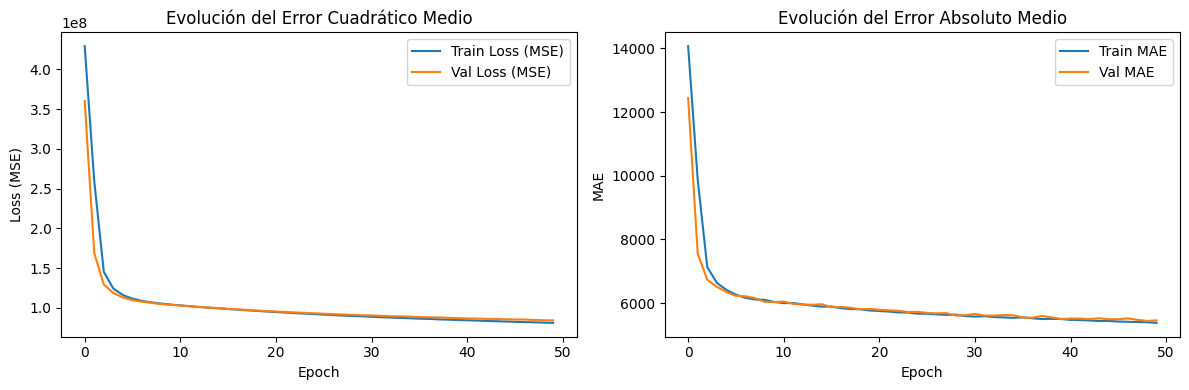

In [3]:
# Hiperparámetros ajustados
n_epochs = 50
batch_size = 32
learning_rate = 0.001 

# Optimizador
optimizer = Adam(learning_rate=learning_rate)

# Modelo
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),

    Dense(32, activation='relu'),

    Dense(1, activation='linear') 
])

model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

# Entrenamiento
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=n_epochs,
    batch_size=batch_size,
    verbose=1
)

model.summary()

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
# Evaluar en test
train_loss, train_mae = model.evaluate(X_train, y_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred) * 100

test_loss, test_mae = model.evaluate(X_test, y_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred) * 100


print(f"\nResultados en TEST y TRAIN:")
print(f"Train -> Loss: {train_loss:.4f}, MAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, R2: {train_r2:.4f} %")
print(f"Test  -> Loss: {test_loss:.4f}, MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R2: {test_r2:.4f} %")

# Visualizar el entrenamiento
plt.figure(figsize=(12, 4))

# Gráfica 1: Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Evolución del Error Cuadrático Medio')

# Gráfica 2: MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('Evolución del Error Absoluto Medio')

plt.tight_layout()
plt.show()


El modelo no es muy bueno haciendo la prediccion pero el train y test se acecan mucho es bueno, pero el modelo puede seguir aprendiendo mas.

# Modificamos Hiperparámetros
### Vamos a subir n_epochs

Epoch 1/200


c:\Users\iabd\AppData\Local\anaconda3\envs\entornoTest\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 427657568.0000 - mae: 14028.4229 - val_loss: 353709888.0000 - val_mae: 12279.8281
Epoch 2/200
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 254937040.0000 - mae: 9776.8311 - val_loss: 165344640.0000 - val_mae: 7514.2783
Epoch 3/200
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 144526720.0000 - mae: 7099.0054 - val_loss: 129017528.0000 - val_mae: 6736.3857
Epoch 4/200
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 123910288.0000 - mae: 6630.7275 - val_loss: 118200984.0000 - val_mae: 6425.9272
Epoch 5/200
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 115886024.0000 - mae: 6388.6221 - val_loss: 112841656.0000 - val_mae: 6300.7305
Epoch 6/200
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 111488904.0000 - mae: 6256.5991 - val_loss: 109626832.0000 - val_mae: 6202.0098
Epoch 7/200
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 108782464.0000 - mae: 6168.2026 - val_loss: 107590136.0000 - val_mae: 6144.8130
Epoch 8/200
510/510 ━━━

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,413 (36.77 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,276 (24.52 KB)

510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 60980596.0000 - mae: 4678.3838
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 69327896.0000 - mae: 4905.9897

Resultados en TEST y TRAIN:
Train -> Loss: 60980596.0000, MAE: 4678.3838, RMSE: 7809.0074, R2: 74.3908 %
Test  -> Loss: 69327896.0000, MAE: 4905.9897, RMSE: 8326.3356, R2: 70.3442 %


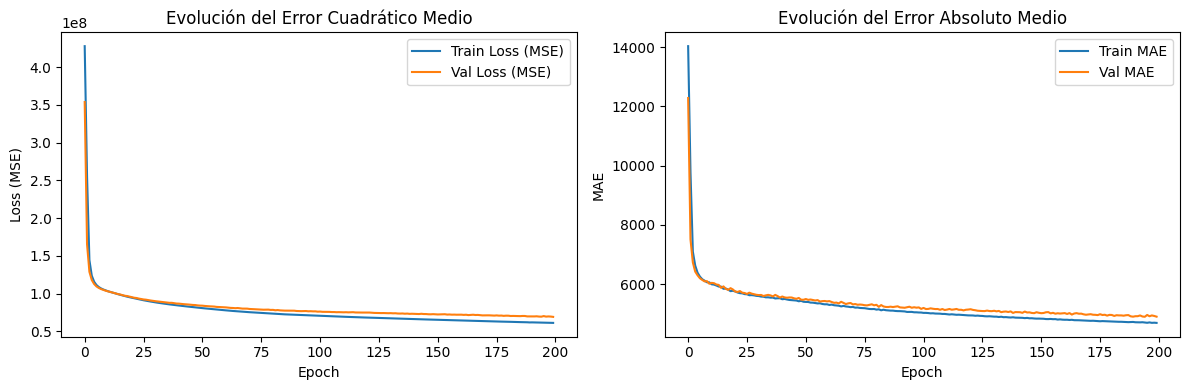

In [4]:
# Hiperparámetros ajustados
n_epochs = 200
batch_size = 32
learning_rate = 0.001 

# Optimizador
optimizer = Adam(learning_rate=learning_rate)

# Modelo
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),

    Dense(32, activation='relu'),

    Dense(1, activation='linear') 
])

model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

# Entrenamiento
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=n_epochs,
    batch_size=batch_size,
    verbose=1
)

model.summary()

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
# Evaluar en test
train_loss, train_mae = model.evaluate(X_train, y_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred) * 100

test_loss, test_mae = model.evaluate(X_test, y_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred) * 100


print(f"\nResultados en TEST y TRAIN:")
print(f"Train -> Loss: {train_loss:.4f}, MAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, R2: {train_r2:.4f} %")
print(f"Test  -> Loss: {test_loss:.4f}, MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R2: {test_r2:.4f} %")

# Visualizar el entrenamiento

plt.figure(figsize=(12, 4))

# Gráfica 1: Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Evolución del Error Cuadrático Medio')

# Gráfica 2: MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('Evolución del Error Absoluto Medio')

plt.tight_layout()
plt.show()

El test se separa un poco mas pero no es preocupante y falla menos

## Creamos otra capa de batch

Epoch 1/200


c:\Users\iabd\AppData\Local\anaconda3\envs\entornoTest\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


510/510 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 245905248.0000 - mae: 9389.4141 - val_loss: 114866832.0000 - val_mae: 6224.0430
Epoch 2/200
510/510 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 107994072.0000 - mae: 6091.2388 - val_loss: 103891368.0000 - val_mae: 5989.5151
Epoch 3/200
510/510 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 100622808.0000 - mae: 5867.3159 - val_loss: 99257304.0000 - val_mae: 5893.8384
Epoch 4/200
510/510 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 96631272.0000 - mae: 5782.3677 - val_loss: 96299168.0000 - val_mae: 5707.6812
Epoch 5/200
510/510 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 93348520.0000 - mae: 5667.5615 - val_loss: 93365368.0000 - val_mae: 5670.3208
Epoch 6/200
510/510 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 90459824.0000 - mae: 5620.0283 - val_loss: 91044032.0000 - val_mae: 5615.5332
Epoch 7/200
510/510 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 88277776.0000 - mae: 5561.9272 - val_loss: 89268664.0000 - val_mae: 5648.4292
Epoch 8/200
510/510 ━━━━━━━━━━━━━━

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,253 (145.52 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 24,836 (97.02 KB)

510/510 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step
510/510 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step - loss: 22980000.0000 - mae: 3280.8013
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - loss: 48765532.0000 - mae: 4164.3130

Resultados en TEST y TRAIN:
Train -> Loss: 22980000.0000, MAE: 3280.8013, RMSE: 4793.7459, R2: 90.3494 %
Test  -> Loss: 48765532.0000, MAE: 4164.3130, RMSE: 6983.2331, R2: 79.1400 %


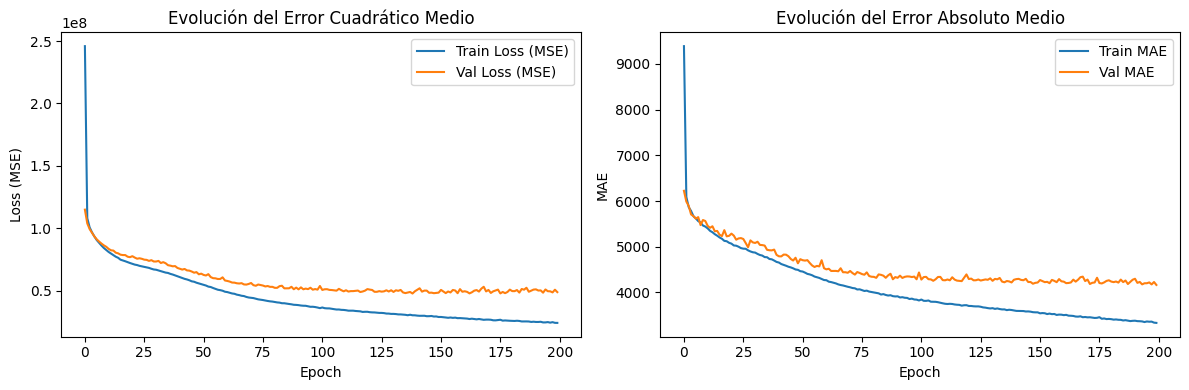

In [5]:
# Hiperparámetros ajustados
n_epochs = 200
batch_size = 32
learning_rate = 0.001 

# Optimizador
optimizer = Adam(learning_rate=learning_rate)

# Modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    
    Dense(64, activation='relu'),

    Dense(32, activation='relu'),

    Dense(1, activation='linear') 
])

model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

# Entrenamiento
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=n_epochs,
    batch_size=batch_size,
    verbose=1
)

model.summary()

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
# Evaluar en test
train_loss, train_mae = model.evaluate(X_train, y_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred) * 100

test_loss, test_mae = model.evaluate(X_test, y_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred) * 100


print(f"\nResultados en TEST y TRAIN:")
print(f"Train -> Loss: {train_loss:.4f}, MAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, R2: {train_r2:.4f} %")
print(f"Test  -> Loss: {test_loss:.4f}, MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R2: {test_r2:.4f} %")

# Visualizar el entrenamiento

plt.figure(figsize=(12, 4))

# Gráfica 1: Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Evolución del Error Cuadrático Medio')

# Gráfica 2: MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('Evolución del Error Absoluto Medio')

plt.tight_layout()
plt.show()

En este caso las lineas se separan mucho, por lo que hay overfitting 

#  Modelo Poniendo Dropout

Epoch 1/500


c:\Users\iabd\AppData\Local\anaconda3\envs\entornoTest\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 442245792.0000 - mae: 14334.0977 - val_loss: 396025408.0000 - val_mae: 13117.5459 - learning_rate: 0.0010
Epoch 2/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 261128736.0000 - mae: 9549.0078 - val_loss: 139274128.0000 - val_mae: 6885.7891 - learning_rate: 0.0010
Epoch 3/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 137059040.0000 - mae: 6878.5435 - val_loss: 120069872.0000 - val_mae: 6482.1230 - learning_rate: 0.0010
Epoch 4/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 124312736.0000 - mae: 6538.3994 - val_loss: 111726768.0000 - val_mae: 6133.0044 - learning_rate: 0.0010
Epoch 5/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 117357064.0000 - mae: 6357.3965 - val_loss: 107053992.0000 - val_mae: 5984.8535 - learning_rate: 0.0010
Epoch 6/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 113053224.0000 - mae: 6194.1821 - val_loss: 104078936.0000 - val_mae: 5935.6816 - learning_rate: 0.0010
Epoch 7/500
128/128 

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,253 (145.52 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 24,836 (97.02 KB)

510/510 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step
510/510 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - loss: 57927704.0000 - mae: 4601.0688
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - loss: 67038068.0000 - mae: 4826.8823

Resultados en TEST y TRAIN:
Train -> Loss: 57927704.0000, MAE: 4601.0688, RMSE: 7611.0238, R2: 75.6729 %
Test  -> Loss: 67038068.0000, MAE: 4826.8823, RMSE: 8187.6783, R2: 71.3237 %


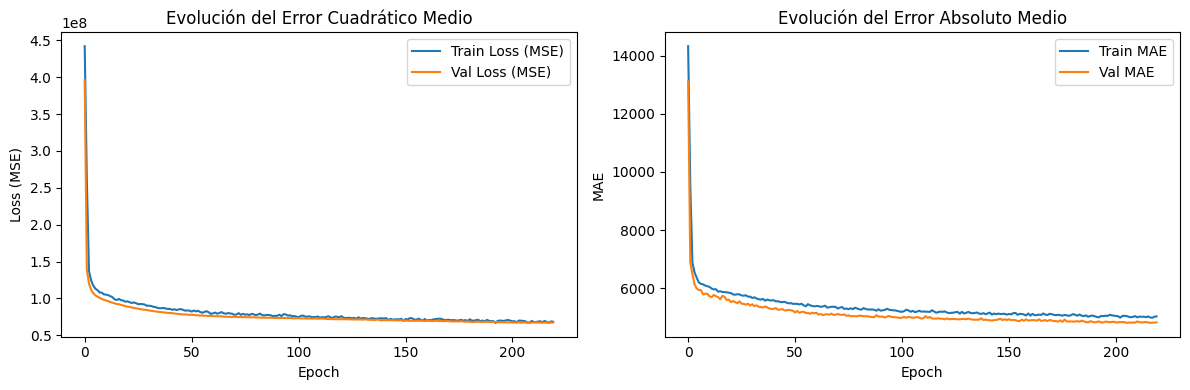

In [6]:
#Hiperparámetros ajustados
n_epochs = 500
batch_size = 128
learning_rate = 0.001 

# Optimizador
optimizer = Adam(learning_rate=learning_rate)

# Modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='linear')  # salida continua
])

model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)

# Entrenamiento
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=n_epochs,
    batch_size=batch_size,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

model.summary()

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
# Evaluar en test
train_loss, train_mae = model.evaluate(X_train, y_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred) * 100

test_loss, test_mae = model.evaluate(X_test, y_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred) * 100


print(f"\nResultados en TEST y TRAIN:")
print(f"Train -> Loss: {train_loss:.4f}, MAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, R2: {train_r2:.4f} %")
print(f"Test  -> Loss: {test_loss:.4f}, MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R2: {test_r2:.4f} %")

# Visualizar el entrenamiento
plt.figure(figsize=(12, 4))

# Gráfica 1: Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Evolución del Error Cuadrático Medio')

# Gráfica 2: MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('Evolución del Error Absoluto Medio')

plt.tight_layout()
plt.show()


El test es poco peor que el anterior pero las lineas se juntan mas, por lo que es mejor modelo

# Con early stopper y dropout

Epoch 1/500


c:\Users\iabd\AppData\Local\anaconda3\envs\entornoTest\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 449476128.0000 - mae: 14541.1992 - val_loss: 437144032.0000 - val_mae: 14264.9932 - learning_rate: 7.0000e-04
Epoch 2/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 449276000.0000 - mae: 14539.7197 - val_loss: 437025984.0000 - val_mae: 14267.2920 - learning_rate: 7.0000e-04
Epoch 3/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 449034240.0000 - mae: 14537.1484 - val_loss: 436846080.0000 - val_mae: 14267.7285 - learning_rate: 7.0000e-04
Epoch 4/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 448740352.0000 - mae: 14533.4922 - val_loss: 436621984.0000 - val_mae: 14265.8066 - learning_rate: 7.0000e-04
Epoch 5/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 448383712.0000 - mae: 14528.8477 - val_loss: 436298784.0000 - val_mae: 14261.4590 - learning_rate: 7.0000e-04
Epoch 6/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 447956000.0000 - mae: 14523.1016 - val_loss: 435935328.0000 - val_mae: 14255.5957 - learning_rat

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,045 (152.52 KB)

 Trainable params: 12,865 (50.25 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 25,732 (100.52 KB)

510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 28842862.0000 - mae: 3487.4551
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 45592672.0000 - mae: 3963.3254

Resultados en TEST y TRAIN:
Train -> Loss: 28842862.0000, MAE: 3487.4551, RMSE: 5370.5538, R2: 87.8873 %
Test  -> Loss: 45592672.0000, MAE: 3963.3254, RMSE: 6752.2346, R2: 80.4972 %


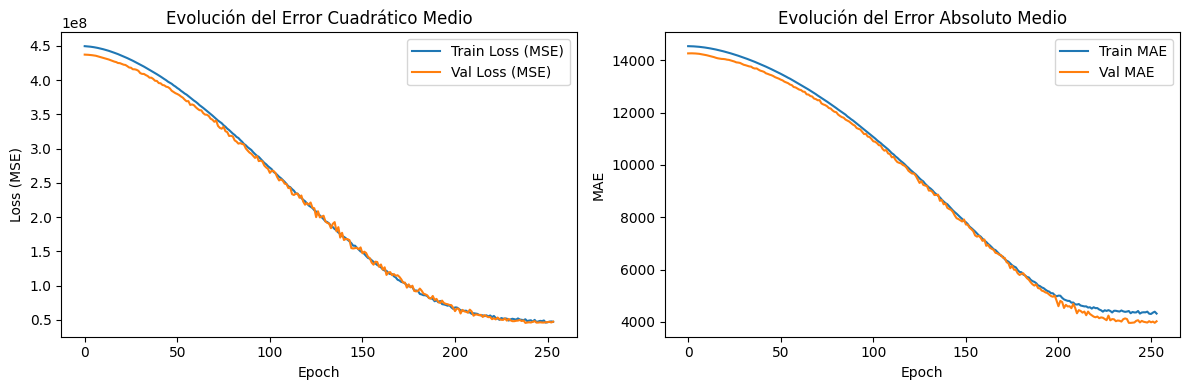

In [7]:
# Hiperparámetros ajustados
n_epochs = 500     
batch_size = 128
learning_rate = 0.0007

# Optimizador
optimizer = Adam(learning_rate=learning_rate)

# Modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='linear')  # salida continua
])

model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)

# Entrenamiento
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=n_epochs,
    batch_size=batch_size,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
model.summary()

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
# Evaluar en test
train_loss, train_mae = model.evaluate(X_train, y_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred) * 100

test_loss, test_mae = model.evaluate(X_test, y_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred) * 100


print(f"\nResultados en TEST y TRAIN:")
print(f"Train -> Loss: {train_loss:.4f}, MAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, R2: {train_r2:.4f} %")
print(f"Test  -> Loss: {test_loss:.4f}, MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R2: {test_r2:.4f} %")

# Visualizar el entrenamiento

plt.figure(figsize=(12, 4))

# Gráfica 1: Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Evolución del Error Cuadrático Medio')

# Gráfica 2: MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('Evolución del Error Absoluto Medio')

plt.tight_layout()
plt.show()

Las lineas se separan un poco pero no es muy preocupante y el modelo falla menos

# Con otra capa más (Mejor Modelo)

Epoch 1/500


c:\Users\iabd\AppData\Local\anaconda3\envs\entornoTest\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 449467904.0000 - mae: 14541.2441 - val_loss: 437160288.0000 - val_mae: 14265.3887 - learning_rate: 7.0000e-04
Epoch 2/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 449270816.0000 - mae: 14539.7812 - val_loss: 437037920.0000 - val_mae: 14267.0430 - learning_rate: 7.0000e-04
Epoch 3/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 449041664.0000 - mae: 14537.3613 - val_loss: 436829440.0000 - val_mae: 14265.8730 - learning_rate: 7.0000e-04
Epoch 4/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 448755360.0000 - mae: 14533.9219 - val_loss: 436516768.0000 - val_mae: 14262.0488 - learning_rate: 7.0000e-04
Epoch 5/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 448407360.0000 - mae: 14529.4648 - val_loss: 436057920.0000 - val_mae: 14256.0244 - learning_rate: 7.0000e-04
Epoch 6/500
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 448012960.0000 - mae: 14524.0000 - val_loss: 435713632.0000 - val_mae: 14251.8330 - learning_rat

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 256)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,925 (570.02 KB)

 Trainable params: 48,321 (188.75 KB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 96,644 (377.52 KB)

510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 948us/step - loss: 17372914.0000 - mae: 2871.6101
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - loss: 38376800.0000 - mae: 3673.6921

Resultados en TEST y TRAIN:
Train -> Loss: 17372914.0000, MAE: 2871.6101, RMSE: 4168.0835, R2: 92.7041 %
Test  -> Loss: 38376800.0000, MAE: 3673.6921, RMSE: 6194.9008, R2: 83.5839 %


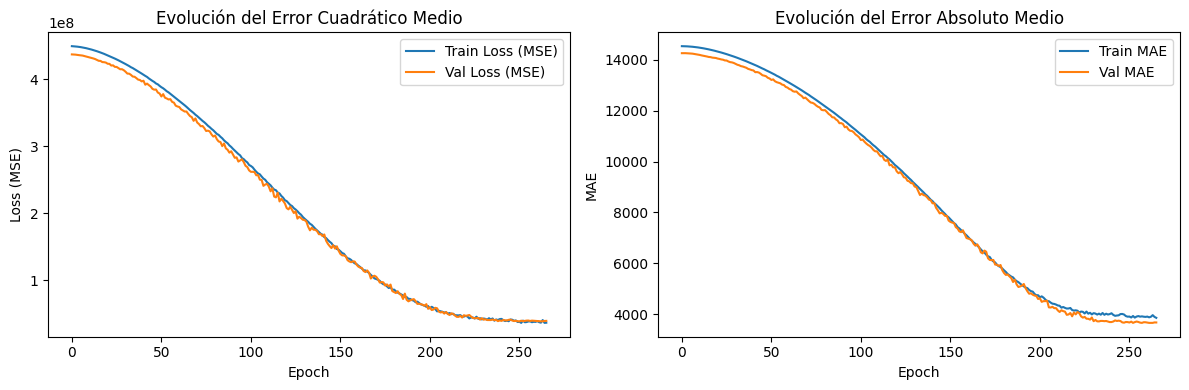

In [8]:
# Hiperparámetros ajustados
n_epochs = 500     
batch_size = 128
learning_rate = 0.0007

# Optimizador
optimizer = Adam(learning_rate=learning_rate)

# Modelo
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='linear')  # salida continua
])

model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)

# Entrenamiento
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=n_epochs,
    batch_size=batch_size,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
model.summary()

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
# Evaluar en test
train_loss, train_mae = model.evaluate(X_train, y_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred) * 100

test_loss, test_mae = model.evaluate(X_test, y_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred) * 100


print(f"\nResultados en TEST y TRAIN:")
print(f"Train -> Loss: {train_loss:.4f}, MAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, R2: {train_r2:.4f} %")
print(f"Test  -> Loss: {test_loss:.4f}, MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R2: {test_r2:.4f} %")

# Visualizar el entrenamiento

plt.figure(figsize=(12, 4))

# Gráfica 1: Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Evolución del Error Cuadrático Medio')

# Gráfica 2: MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('Evolución del Error Absoluto Medio')

plt.tight_layout()
plt.show()


La prediccion ha mejorado mas de lo que se han separado train y test por lo que creemos que sera mejor modelo

# Con más size

Epoch 1/500


c:\Users\iabd\AppData\Local\anaconda3\envs\entornoTest\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 449502624.0000 - mae: 14541.4072 - val_loss: 437188448.0000 - val_mae: 14264.5830 - learning_rate: 8.0000e-04
Epoch 2/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 449369088.0000 - mae: 14540.7773 - val_loss: 437179424.0000 - val_mae: 14267.6445 - learning_rate: 8.0000e-04
Epoch 3/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 449252032.0000 - mae: 14539.8408 - val_loss: 437182560.0000 - val_mae: 14270.3057 - learning_rate: 8.0000e-04
Epoch 4/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 449123424.0000 - mae: 14538.5654 - val_loss: 437101952.0000 - val_mae: 14270.1699 - learning_rate: 8.0000e-04
Epoch 5/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 448975840.0000 - mae: 14536.9238 - val_loss: 437011008.0000 - val_mae: 14269.5850 - learning_rate: 8.0000e-04
Epoch 6/500
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 448802880.0000 - mae: 14534.9727 - val_loss: 436915872.0000 - val_mae: 14269.1699 - learning_rate: 8.0000e-0

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 256)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,925 (570.02 KB)

 Trainable params: 48,321 (188.75 KB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 96,644 (377.52 KB)

510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 14968459.0000 - mae: 2682.1311
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 37906660.0000 - mae: 3598.0496

Resultados en TEST y TRAIN:
Train -> Loss: 14968459.0000, MAE: 2682.1311, RMSE: 3868.9091, R2: 93.7139 %
Test  -> Loss: 37906660.0000, MAE: 3598.0496, RMSE: 6156.8388, R2: 83.7850 %


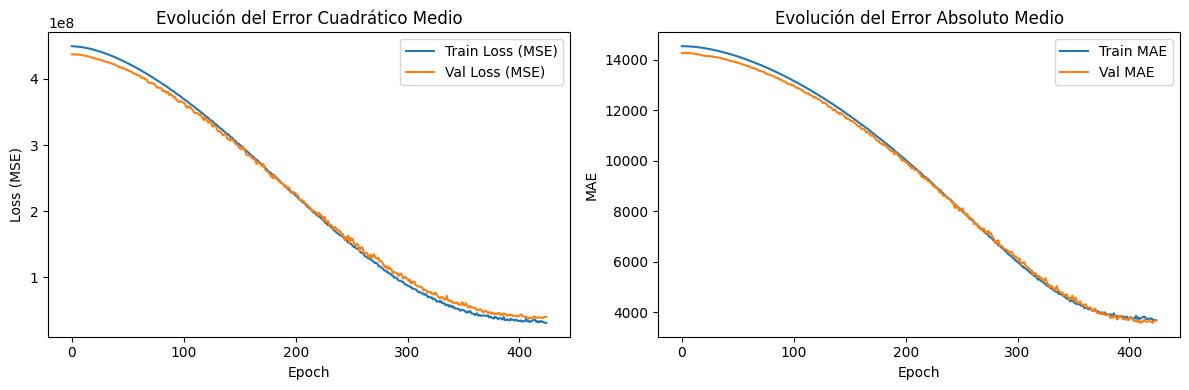

In [9]:
# Hiperparámetros ajustados
n_epochs = 500     
batch_size = 256
learning_rate = 0.0008

# Optimizador
optimizer = Adam(learning_rate=learning_rate)

# Modelo
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='linear')  # salida continua
])

model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)

# Entrenamiento
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=n_epochs,
    batch_size=batch_size,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
model.summary()

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
# Evaluar en test
train_loss, train_mae = model.evaluate(X_train, y_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred) * 100

test_loss, test_mae = model.evaluate(X_test, y_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred) * 100


print(f"\nResultados en TEST y TRAIN:")
print(f"Train -> Loss: {train_loss:.4f}, MAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, R2: {train_r2:.4f} %")
print(f"Test  -> Loss: {test_loss:.4f}, MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R2: {test_r2:.4f} %")

# Visualizar el entrenamiento

plt.figure(figsize=(12, 4))

# Gráfica 1: Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Evolución del Error Cuadrático Medio')

# Gráfica 2: MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('Evolución del Error Absoluto Medio')

plt.tight_layout()
plt.show()

Este modelo ha empeorado train y test se separan mas y falla mas